# 03. Thermodynamics: a trend with a confidence interval attached

Adsorption papers routinely report three thermodynamic quantities to three
decimal places from a five-point regression, with no uncertainty. This notebook
reports the same regression with its confidence intervals, which changes what
can be claimed from it.

One experimental caveat governs everything below: each flask was held at the
set temperature for only 20 min, then shaken for 120 min on an unheated shaker.
The stated temperatures describe a pre-equilibration step, not the contact
temperature. Magnitudes are therefore approximate; only the direction is
defensible.

In [1]:
import sys
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, t as tdist

from adsorption import concentration, removal_pct, uptake, R_GAS

raw = pd.read_csv("data/aas_readings.csv")
CONTROL_READING = {m: float(
    raw.loc[(raw.series == "control") & (raw.metal == m), "reading_mg_L"].iloc[0])
    for m in ["Mn", "Zn"]}

temp = raw[(raw.series == "temperature") & raw.temp_C.notna()].copy()
temp["T_K"] = temp["temp_C"] + 273.15
# Kc = (C0 - Ce)/Ce is dimensionless, so the dilution factor cancels and the
# readings can be used directly.
temp["Kc"] = [(CONTROL_READING[m] - r) / r
              for m, r in zip(temp.metal, temp.reading_mg_L)]
temp["ln_Kc"] = np.log(temp["Kc"])
temp["removal_pct"] = [removal_pct(CONTROL_READING[m], r)
                       for m, r in zip(temp.metal, temp.reading_mg_L)]

for metal in ["Mn", "Zn"]:
    d = temp[temp.metal == metal].sort_values("T_K")
    print(f"=== {metal}(II) ===")
    print(d[["temp_C", "T_K", "reading_mg_L", "removal_pct", "Kc",
             "ln_Kc"]].round(3).to_string(index=False))
    print()

=== Mn(II) ===
 temp_C    T_K  reading_mg_L  removal_pct    Kc  ln_Kc
   27.0 300.15         10.39       20.687 0.261 -1.344
   37.0 310.15         11.83        9.695 0.107 -2.232
   47.0 320.15         11.50       12.214 0.139 -1.972
   57.0 330.15         12.06        7.939 0.086 -2.451
   67.0 340.15         12.30        6.107 0.065 -2.733

=== Zn(II) ===
 temp_C    T_K  reading_mg_L  removal_pct    Kc  ln_Kc
   27.0 300.15         1.423       50.262 1.011  0.010
   37.0 310.15         1.301       54.526 1.199  0.182
   47.0 320.15         1.750       38.833 0.635 -0.454
   57.0 330.15         2.352       17.791 0.216 -1.531
   67.0 340.15         1.681       41.244 0.702 -0.354



## The van't Hoff regression

$$\ln K_c = \frac{\Delta S^\circ}{R} - \frac{\Delta H^\circ}{RT}$$

Fitted by ordinary least squares over five temperatures, which leaves three
degrees of freedom. The 95% intervals come from the regression standard errors
and the t distribution, not from the spread of the points.

In [2]:
TCRIT = tdist.ppf(0.975, df=3)
results = {}

for metal in ["Mn", "Zn"]:
    d = temp[temp.metal == metal].sort_values("T_K")
    lr = linregress(1.0 / d["T_K"], d["ln_Kc"])
    dH = -lr.slope * R_GAS / 1000.0                 # kJ/mol
    dH_ci = TCRIT * lr.stderr * R_GAS / 1000.0
    dS = lr.intercept * R_GAS                        # J/mol/K
    dS_ci = TCRIT * lr.intercept_stderr * R_GAS
    results[metal] = dict(lr=lr, dH=dH, dH_ci=dH_ci, dS=dS, dS_ci=dS_ci, d=d)

    print(f"=== {metal}(II) ===")
    print(f"  ln Kc = {lr.slope:.0f}/T {lr.intercept:+.2f}")
    print(f"  R2 = {lr.rvalue**2:.2f}   p = {lr.pvalue:.3f}")
    print(f"  dH = {dH:+.1f} +/- {dH_ci:.1f} kJ/mol      "
          f"(95% CI {dH - dH_ci:+.1f} to {dH + dH_ci:+.1f})")
    print(f"  dS = {dS:+.0f} +/- {dS_ci:.0f} J/mol/K")
    print()

=== Mn(II) ===
  ln Kc = 3073/T -11.77
  R2 = 0.81   p = 0.037
  dH = -25.6 +/- 22.7 kJ/mol      (95% CI -48.2 to -2.9)
  dS = -98 +/- 71 J/mol/K

=== Zn(II) ===
  ln Kc = 2537/T -8.37
  R2 = 0.35   p = 0.297
  dH = -21.1 +/- 53.3 kJ/mol      (95% CI -74.4 to +32.2)
  dS = -70 +/- 167 J/mol/K



The two metals give opposite situations from identical-looking regressions.

**Mn(II)**: p = 0.037, and the confidence interval for the enthalpy lies
entirely below zero. An exothermic trend is supported.

**Zn(II)**: p = 0.30, and the interval runs from about -74 to +33 kJ/mol. It
contains zero, so it contains both exothermic and endothermic behaviour. No
temperature dependence is established, and reporting a single number for the
Zn(II) enthalpy would be reporting the midpoint of an interval that answers no
question.

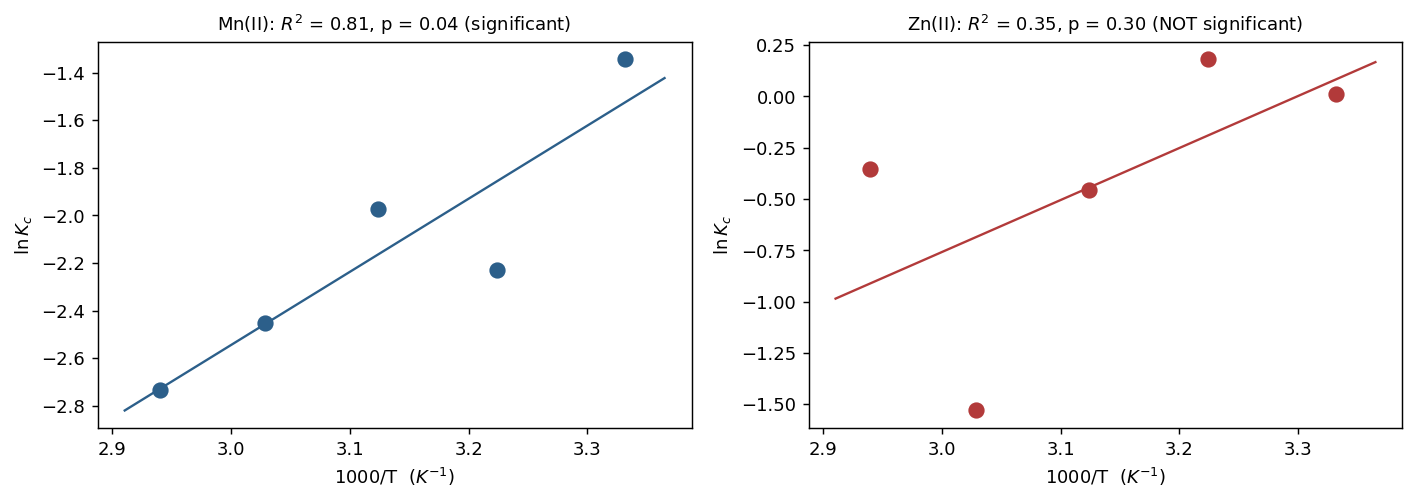

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
for ax, metal in zip(axes, ["Mn", "Zn"]):
    r = results[metal]
    d, lr = r["d"], r["lr"]
    x = 1000.0 / d["T_K"].to_numpy()
    colour = "#2c5f8a" if metal == "Mn" else "#b23a3a"
    ax.plot(x, d["ln_Kc"], "o", color=colour, ms=8)
    grid = np.linspace(x.min() * 0.99, x.max() * 1.01, 100)
    ax.plot(grid, lr.intercept + lr.slope * grid / 1000.0, "-",
            color=colour, lw=1.3)
    sig = "significant" if lr.pvalue < 0.05 else "NOT significant"
    ax.set_title(f"{metal}(II): $R^2$ = {lr.rvalue**2:.2f}, p = {lr.pvalue:.2f} "
                 f"({sig})", fontsize=10)
    ax.set_xlabel("1000/T  ($K^{-1}$)")
    ax.set_ylabel("$\\ln K_c$")
fig.tight_layout()

## The sign of the Gibbs energy is a choice of standard state

`Kc = (C0 - Ce)/Ce` is dimensionless and gives a positive dG. The widely used
alternative, `Kd x 1000` where `Kd = qe/Ce` in L/g, gives a negative dG from the
same measurements.

Many papers present the negative value as evidence of spontaneity without
stating which constant was used. Both are shown here.

In [4]:
d = results["Mn"]["d"]
V_OVER_M = 0.05 / 0.6          # L/g, so Kd = Kc * V/m
rows = []
for _, row in d.iterrows():
    kc = row["Kc"]
    kd = kc * V_OVER_M
    rows.append({
        "T (K)": round(row["T_K"], 2),
        "Kc": round(kc, 3),
        "ln Kc": round(np.log(kc), 2),
        "dG from Kc (kJ/mol)": round(-R_GAS * row["T_K"] * np.log(kc) / 1000, 2),
        "dG from Kd x 1000 (kJ/mol)": round(
            -R_GAS * row["T_K"] * np.log(kd * 1000) / 1000, 2)})

print("Mn(II):")
print(pd.DataFrame(rows).to_string(index=False))
print()
print("Same data, opposite signs. What both conventions agree on is the")
print("direction: the inferred favourability decreases as temperature rises.")
print("That direction is the result. The sign of dG is not.")

Mn(II):
 T (K)    Kc  ln Kc  dG from Kc (kJ/mol)  dG from Kd x 1000 (kJ/mol)
300.15 0.261  -1.34                 3.35                       -7.68
310.15 0.107  -2.23                 5.75                       -5.65
320.15 0.139  -1.97                 5.25                       -6.52
330.15 0.086  -2.45                 6.73                       -5.41
340.15 0.065  -2.73                 7.73                       -4.78

Same data, opposite signs. What both conventions agree on is the
direction: the inferred favourability decreases as temperature rises.
That direction is the result. The sign of dG is not.


In [5]:
# Sensitivity: the laboratory reported six readings for five temperatures.
# The sixth is unassigned. Does using it as the reference change the answer?
alt_ref = float(raw[(raw.metal == "Mn") &
                    (raw.label == "temp_sixth")]["reading_mg_L"].iloc[0])
d = results["Mn"]["d"]
kc_alt = (alt_ref - d["reading_mg_L"]) / d["reading_mg_L"]
lr_alt = linregress(1.0 / d["T_K"], np.log(kc_alt))
dH_alt = -lr_alt.slope * R_GAS / 1000
ci_alt = TCRIT * lr_alt.stderr * R_GAS / 1000

print(f"Mn(II) using the measured control as reference: "
      f"dH = {results['Mn']['dH']:+.1f} +/- {results['Mn']['dH_ci']:.1f} kJ/mol")
print(f"Mn(II) using the unassigned sixth reading:      "
      f"dH = {dH_alt:+.1f} +/- {ci_alt:.1f} kJ/mol")
print()
print("The sign and rough magnitude survive the ambiguity in the laboratory")
print("record, which is the most that can be claimed for a series that was")
print("temperature-controlled for 20 of its 140 minutes.")

Mn(II) using the measured control as reference: dH = -25.6 +/- 22.7 kJ/mol
Mn(II) using the unassigned sixth reading:      dH = -22.1 +/- 20.2 kJ/mol

The sign and rough magnitude survive the ambiguity in the laboratory
record, which is the most that can be claimed for a series that was
temperature-controlled for 20 of its 140 minutes.


## Conclusions

- **Mn(II)**: removal falls from 20.7% at 27 C to 6.1% at 67 C. The van't Hoff
  regression is significant (p = 0.037) and gives an apparent
  dH = -25.6 +/- 22.7 kJ/mol, consistent with an exothermic trend. The interval
  is almost as wide as the estimate, so the direction is the finding and the
  magnitude is provisional.
- **Zn(II)**: no temperature dependence is established (p = 0.30). No
  thermodynamic quantities are reported for Zn(II), because the honest output
  of this analysis is that there isn't one.
- The sign of dG depends on the equilibrium-constant convention and is not by
  itself evidence of spontaneity.

Fixing this needs a thermostatted shaker so each temperature is held for the
full contact period, which is recommendation 6 in the thesis.